<a href="https://colab.research.google.com/github/EmmanuelJulius/EART60702_project2_group3/blob/Emmanuel/003_manchester_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf
import warnings

warnings.filterwarnings('ignore')

# ────────────────────────────────────────────────
#  SETTINGS
# ────────────────────────────────────────────────
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("muted")
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['figure.figsize'] = (10, 5)

FILE_PATH = "003_manchester_processed.csv"   # ← change if needed

# Key variables to focus on
KEY_VARS = ['TREFMXAV_U', 'TREFHT', 'PRECT', 'FLNS', 'FSNS', 'PRSN', 'QBOT', 'UBOT', 'VBOT']

In [2]:
# ────────────────────────────────────────────────
# 1. Load & Prepare
# ────────────────────────────────────────────────
df = pd.read_csv(FILE_PATH, parse_dates=['time'])
df['year'] = df['time'].dt.year
df['month'] = df['time'].dt.month
df['dayofyear'] = df['time'].dt.dayofyear

print("Shape:", df.shape)
print("Date range:", df['time'].min(), "–", df['time'].max())
print("Missing values:\n", df.isna().sum())

Shape: (26325, 16)
Date range: 2006-01-02 00:00:00 – 2080-12-31 00:00:00
Missing values:
 time          0
TREFMXAV_U    0
FLNS          0
FSNS          0
PRECT         0
PRSN          0
QBOT          0
TREFHT        0
UBOT          0
VBOT          0
lat           0
lon           0
year          0
month         0
day           0
dayofyear     0
dtype: int64


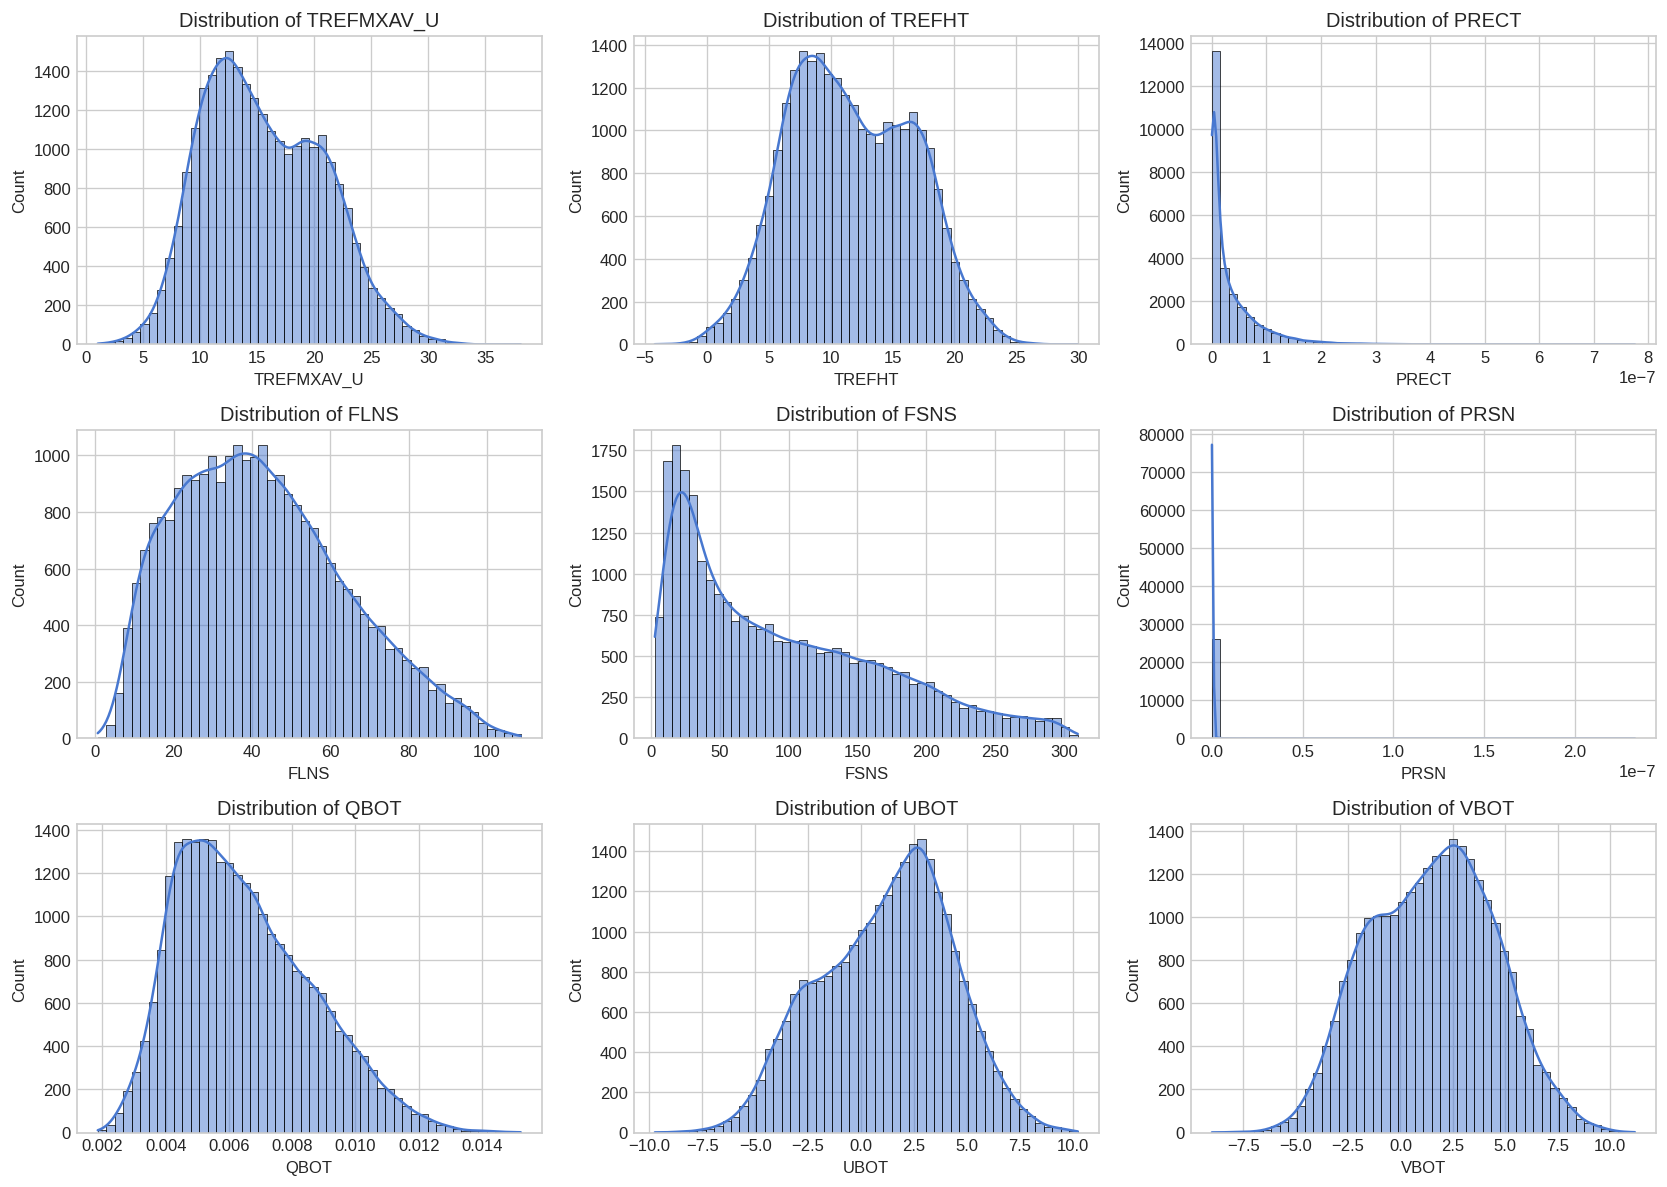

In [3]:
# ────────────────────────────────────────────────
# 2. Distributions – Histograms
# ────────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.ravel()

for i, var in enumerate(KEY_VARS):
    sns.histplot(data=df, x=var, ax=axes[i], kde=True, bins=50)
    axes[i].set_title(f'Distribution of {var}')

plt.tight_layout()
plt.savefig('distributions_key_vars.png', bbox_inches='tight')
plt.show()

Distributions are approximately normal for temperatures (with clear spread) but right-skewed for precipitation variables (many near-zero days + rare heavy events).

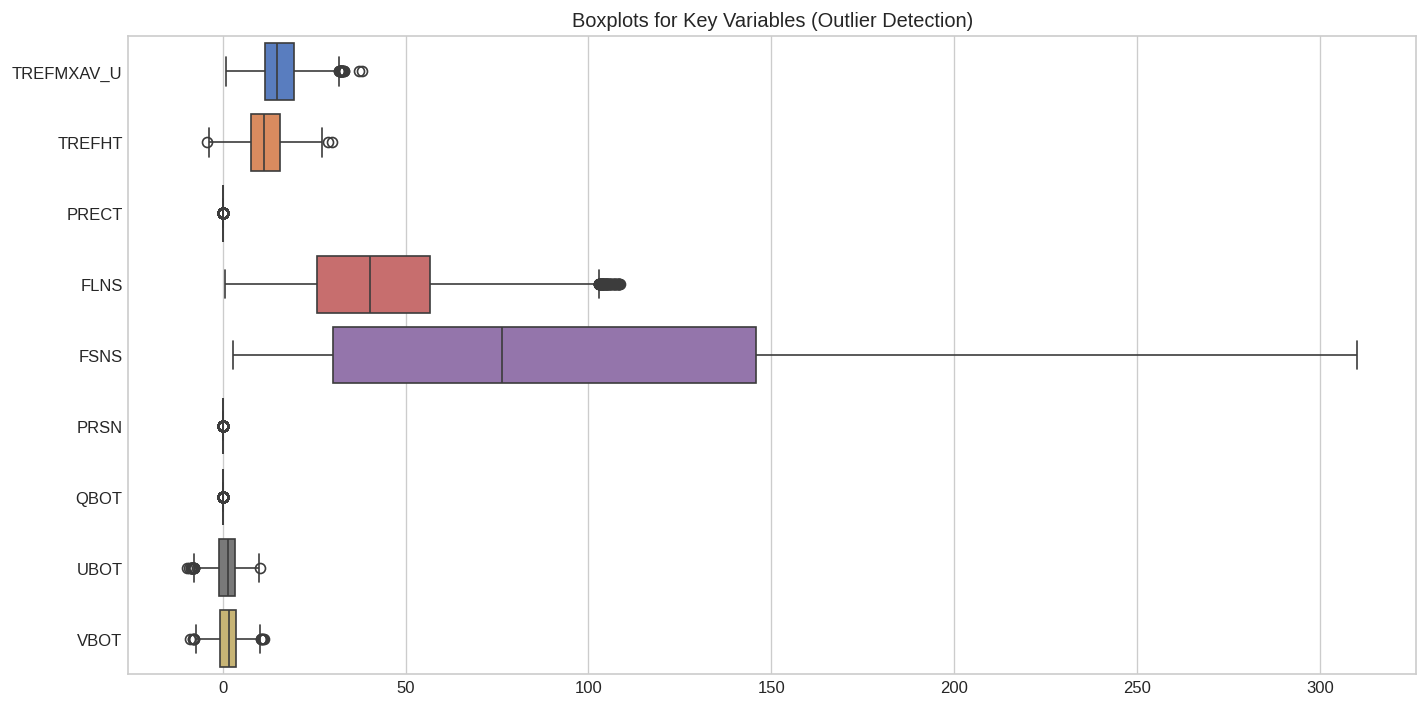

In [4]:
# ────────────────────────────────────────────────
# 3. Boxplots (outlier overview)
# ────────────────────────────────────────────────
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[KEY_VARS], orient='h', whis=1.5)
plt.title('Boxplots for Key Variables (Outlier Detection)')
plt.tight_layout()
plt.savefig('boxplots_key_vars.png', bbox_inches='tight')
plt.show()

Boxplots confirm occasional outliers in fluxes and precip, which is physically expected in daily climate data and unlikely to harm prediction if models handle extremes well.

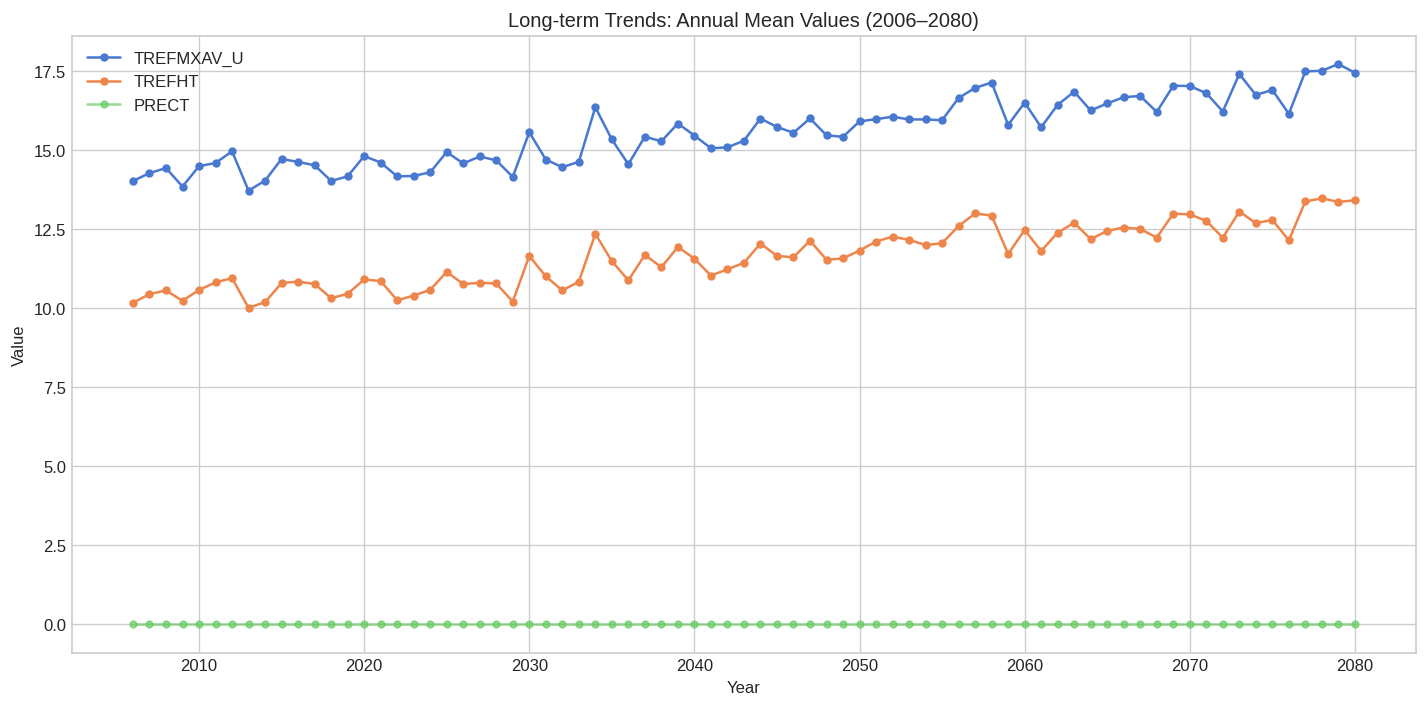

In [5]:
# ────────────────────────────────────────────────
# 4. Long-term trend – Annual means
# ────────────────────────────────────────────────
annual = df.groupby('year')[['TREFMXAV_U', 'TREFHT', 'PRECT']].mean().reset_index()

plt.figure(figsize=(12, 6))
plt.plot(annual['year'], annual['TREFMXAV_U'], label='TREFMXAV_U', marker='o', ms=4)
plt.plot(annual['year'], annual['TREFHT'],    label='TREFHT',    marker='o', ms=4)
plt.plot(annual['year'], annual['PRECT'],     label='PRECT',     marker='o', ms=4, alpha=0.7)
plt.title('Long-term Trends: Annual Mean Values (2006–2080)')
plt.xlabel('Year')
plt.ylabel('Value')
plt.legend()
plt.tight_layout()
plt.savefig('long_term_annual_trends.png', bbox_inches='tight')
plt.show()

Long-term trends: Strong warming signal. Annual mean TREFMXAV_U rises from ≈14.02 in 2006 to ≈17.44 in 2080 (+3.42 °C overall). TREFHT follows the same upward trajectory. Precipitation shows interannual fluctuation but no clear monotonic trend.

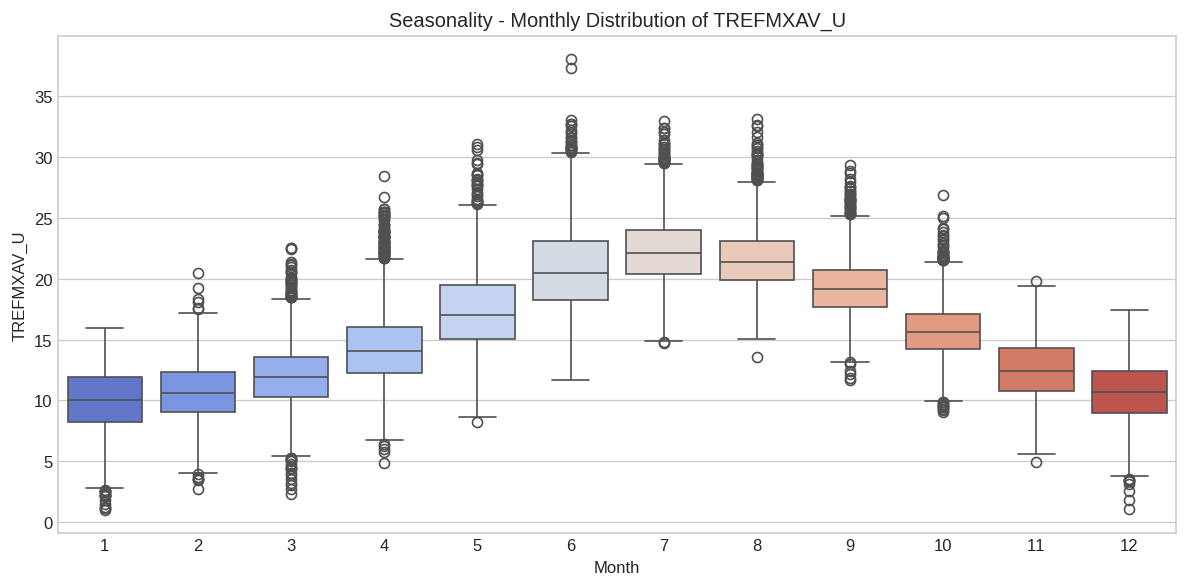

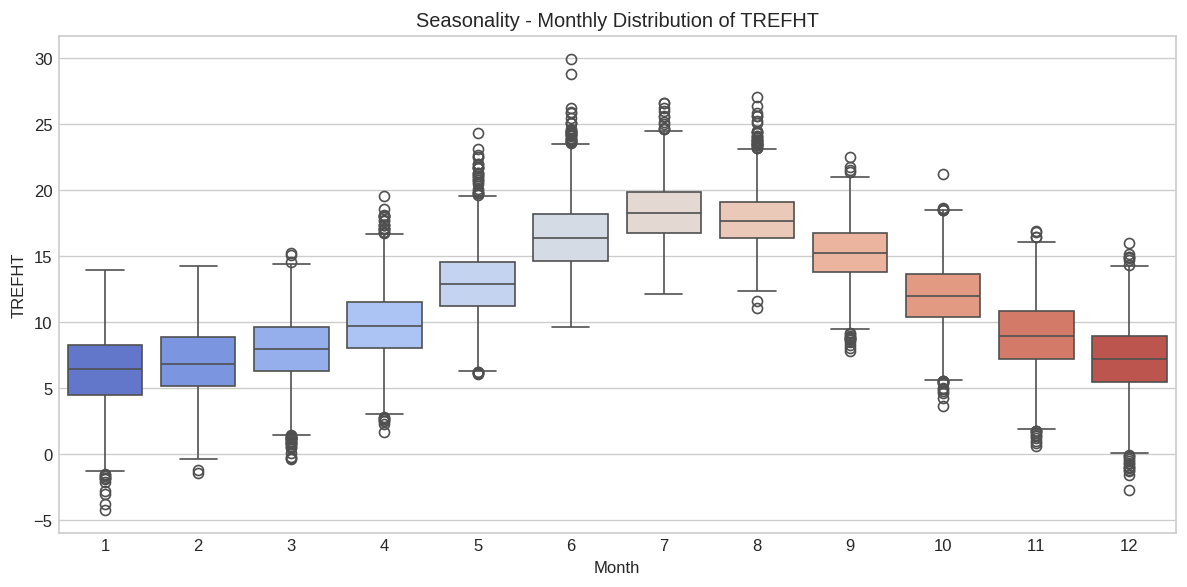

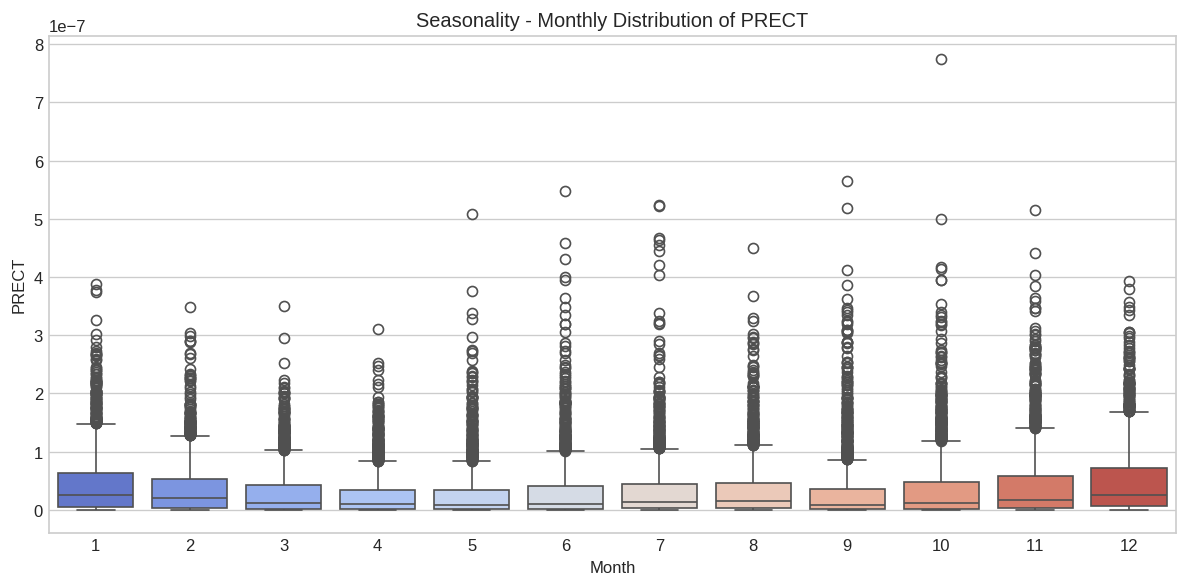

In [6]:
# ────────────────────────────────────────────────
# 5. Seasonality – Monthly boxplots
# ────────────────────────────────────────────────
for var in ['TREFMXAV_U', 'TREFHT', 'PRECT']:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x='month', y=var, data=df, palette='coolwarm')
    plt.title(f'Seasonality - Monthly Distribution of {var}')
    plt.xlabel('Month')
    plt.tight_layout()
    plt.savefig(f'seasonality_monthly_{var.lower()}.png', bbox_inches='tight')
    plt.show()

Seasonality: Classic Northern Hemisphere cycle. Monthly means peak in July (≈22.35 for TREFMXAV_U) and bottom in January (≈9.96). Boxplots reveal higher variability in winter for temperature and more outlier-prone precipitation in transitional seasons. Day-of-year smoothed cycle confirms the smooth sinusoidal pattern.

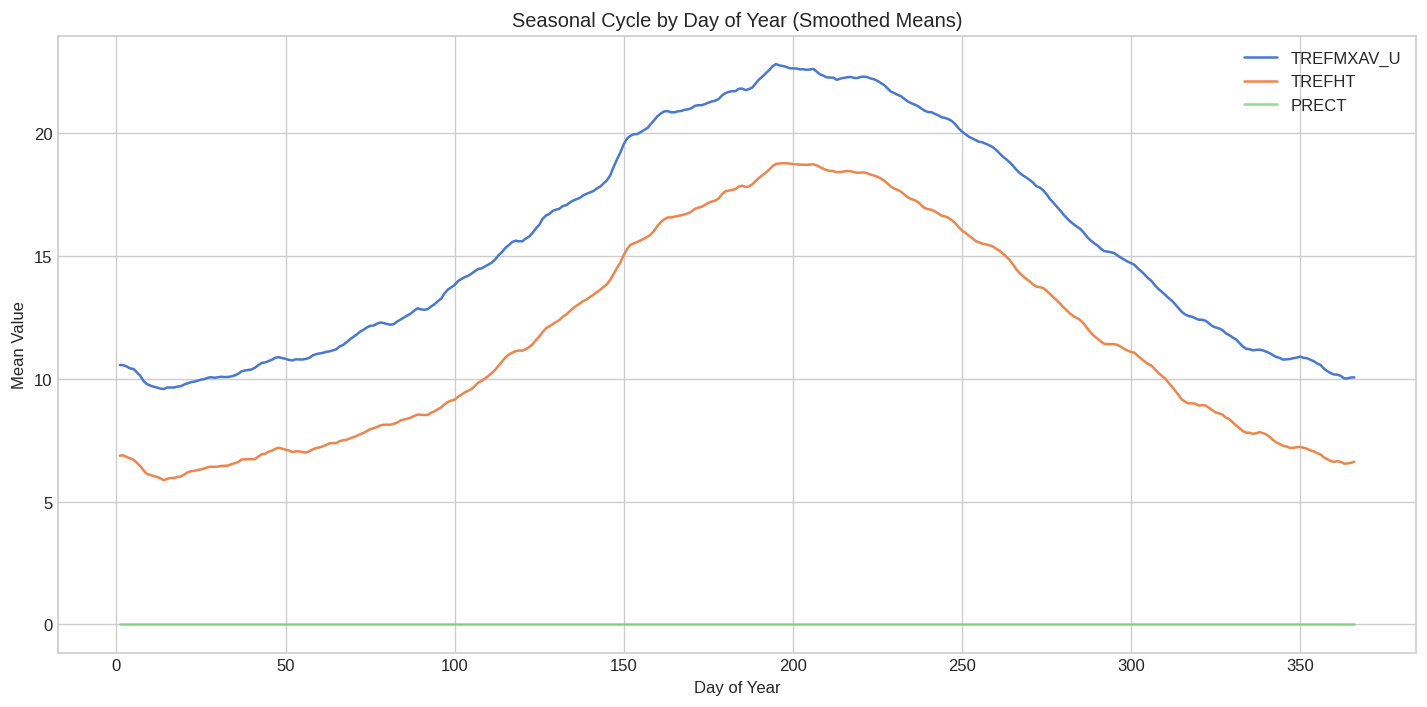

In [7]:
# ────────────────────────────────────────────────
# 6. Smoothed seasonal cycle by day of year
# ────────────────────────────────────────────────
doy_mean = df.groupby('dayofyear')[['TREFMXAV_U', 'TREFHT', 'PRECT']].mean()
# 7-day rolling mean for smoother curve
doy_smooth = doy_mean.rolling(window=7, center=True, min_periods=1).mean()

plt.figure(figsize=(12, 6))
plt.plot(doy_smooth.index, doy_smooth['TREFMXAV_U'], label='TREFMXAV_U')
plt.plot(doy_smooth.index, doy_smooth['TREFHT'],    label='TREFHT')
plt.plot(doy_smooth.index, doy_smooth['PRECT'],     label='PRECT', alpha=0.7)
plt.title('Seasonal Cycle by Day of Year (Smoothed Means)')
plt.xlabel('Day of Year')
plt.ylabel('Mean Value')
plt.legend()
plt.tight_layout()
plt.savefig('seasonal_cycle_dayofyear.png', bbox_inches='tight')
plt.show()

Fluctuation: Daily noise is high, but seasonality dominates; interannual variability is visible in the annual line plot (e.g., cooler years around 2009–2010). The 74-year span makes long-term climate signal clear while preserving short-term weather realism.

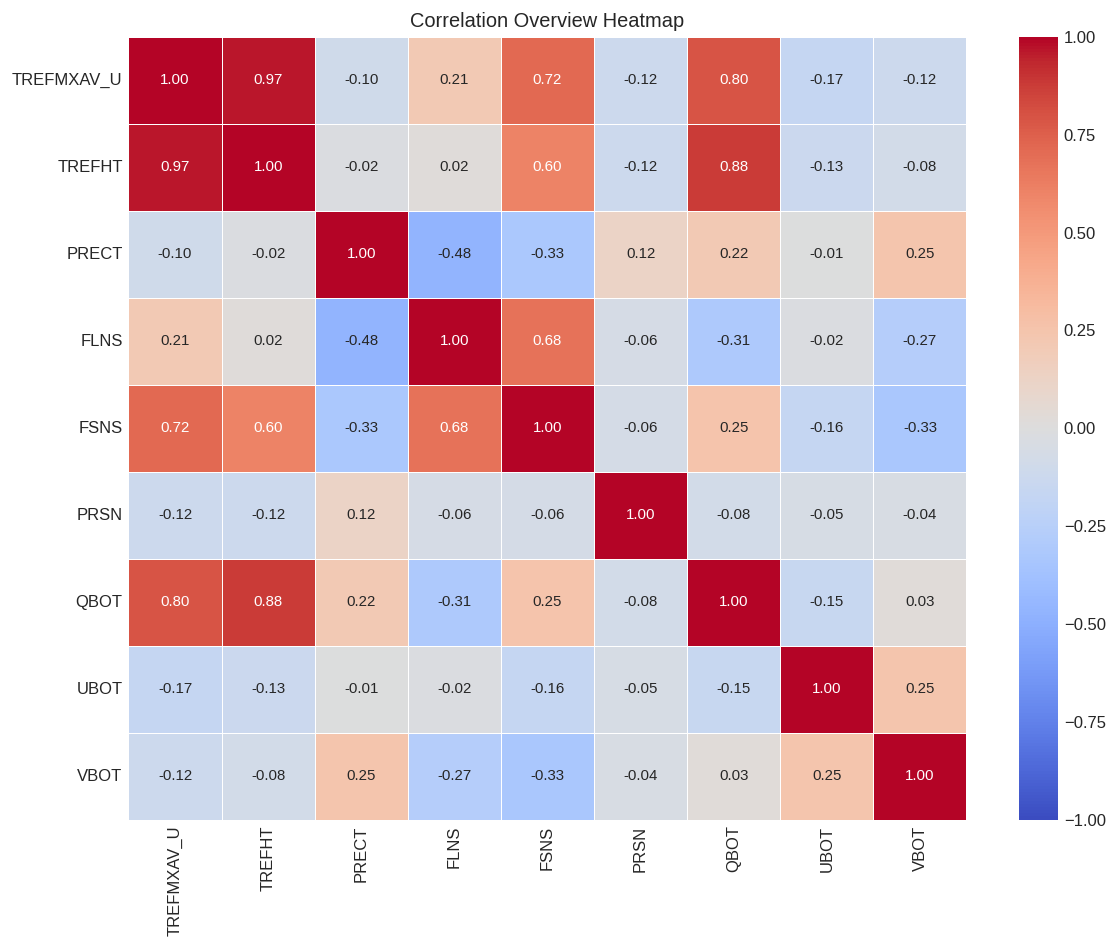

In [8]:
# ────────────────────────────────────────────────
# 7. Correlation heatmap
# ────────────────────────────────────────────────
corr = df[KEY_VARS].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={'size': 9})
plt.title('Correlation Overview Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', bbox_inches='tight')
plt.show()

Correlation Overview:
Strong positive correlations among temperature variables (0.97) and with humidity QBOT (0.80–0.88). Radiation fluxes correlate positively with temperature but negatively with precipitation. Precip variables show weak negative or near-zero links to temperature — typical for mid-latitude climates.

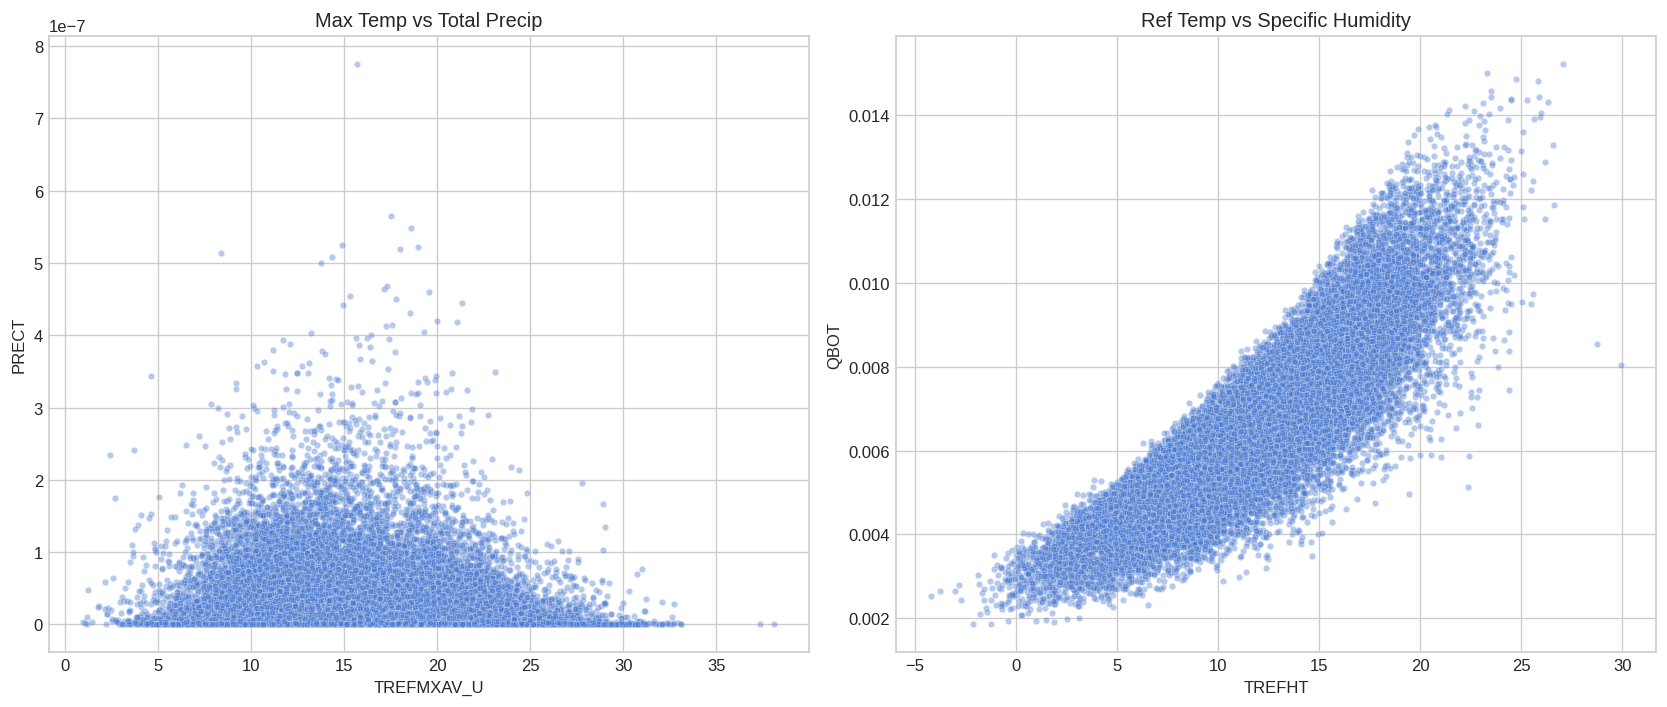

In [9]:
# ────────────────────────────────────────────────
# 8. Example multivariate scatter plots
# ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(x='TREFMXAV_U', y='PRECT', data=df, ax=axes[0], alpha=0.4, s=15)
axes[0].set_title('Max Temp vs Total Precip')
axes[0].set_xlabel('TREFMXAV_U')
axes[0].set_ylabel('PRECT')

sns.scatterplot(x='TREFHT', y='QBOT', data=df, ax=axes[1], alpha=0.4, s=15)
axes[1].set_title('Ref Temp vs Specific Humidity')
axes[1].set_xlabel('TREFHT')
axes[1].set_ylabel('QBOT')

plt.tight_layout()
plt.savefig('multivariate_scatter_examples.png', bbox_inches='tight')
plt.show()

Univariate: Already covered in the histograms above — temperatures are symmetric, precipitation heavily skewed (many dry days).

Multivariate: Scatter samples confirm a mild negative relationship between temperature and precipitation (warmer conditions slightly drier on average) and a very tight positive link between temperature and humidity.

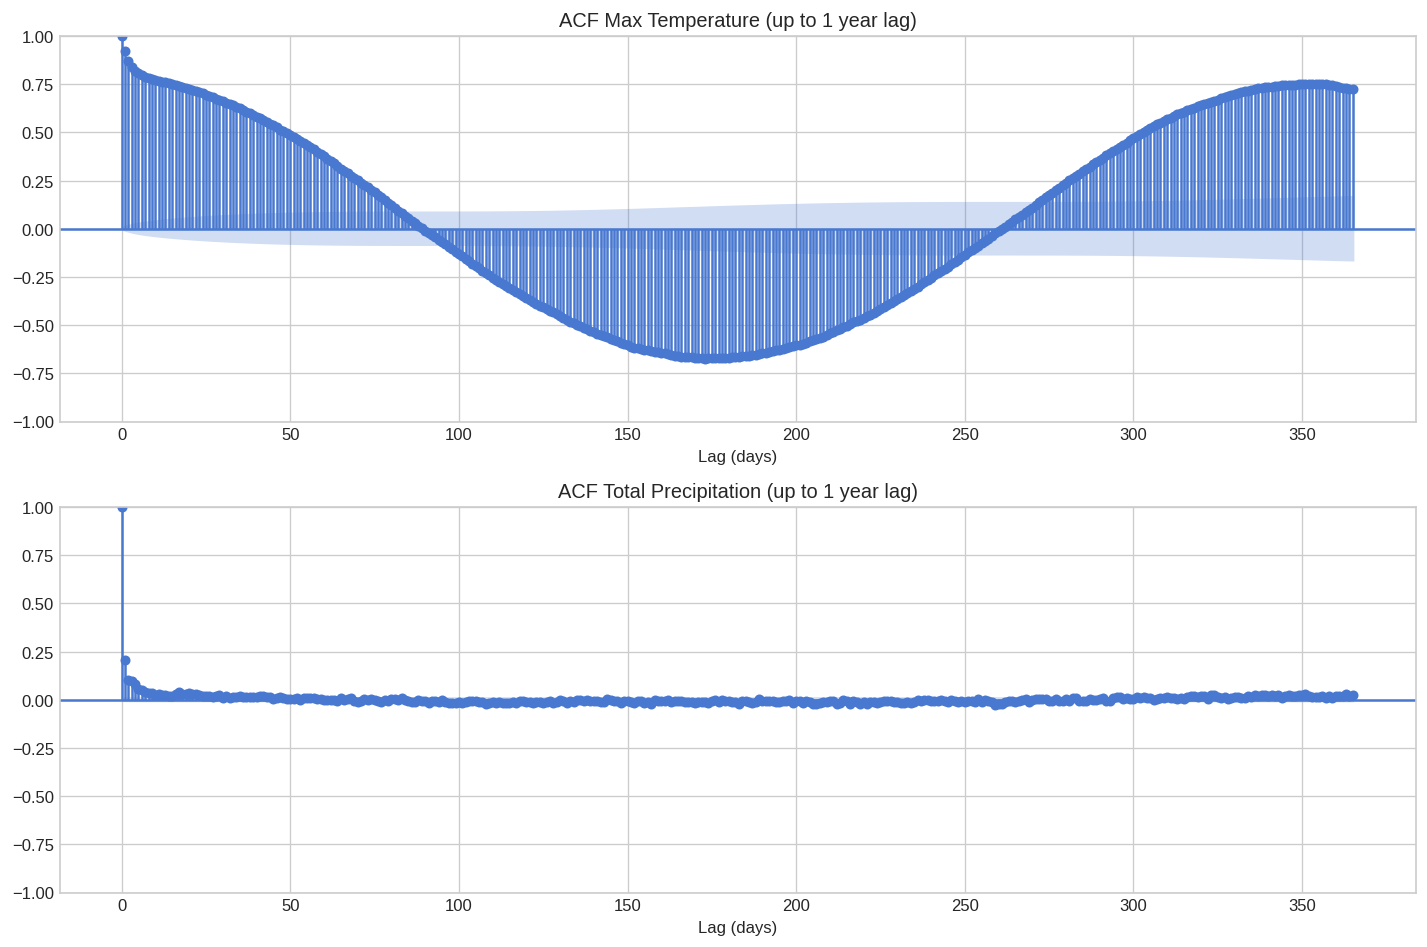

In [11]:
# ────────────────────────────────────────────────
# 9. ACF (lag analysis) – up to 365 days
# ────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

plot_acf(df['TREFMXAV_U'], lags=365, ax=axes[0], title='ACF Max Temperature (up to 1 year lag)')
axes[0].set_xlabel('Lag (days)')

plot_acf(df['PRECT'], lags=365, ax=axes[1], title='ACF Total Precipitation (up to 1 year lag)')
axes[1].set_xlabel('Lag (days)')

plt.tight_layout()
plt.savefig('lag_analysis_acf.png', bbox_inches='tight')
plt.show()

Lag analysis: Autocorrelation Function (ACF) up to 365-day lags shows very strong seasonal persistence in temperature (peaks recur every ≈365 days). Precipitation autocorrelation decays faster with weaker seasonal echo — useful for time-series feature engineering or lag-based models.